# Clusterização de Regimes de Volatilidade

Os módulos de Estatística e Econometria deste curso são majoritariamente
**supervisionados**: sempre havia uma variável dependente conhecida a explicar. Este
notebook usa **aprendizado não-supervisionado** — K-Means — para uma pergunta diferente:
será que dá para identificar automaticamente, sem rótulo nenhum, quais períodos do
mercado se comportam de um jeito parecido entre si (calmo, moderado, turbulento)? A
resposta se conecta diretamente com a heterocedasticidade condicional estudada no
[Módulo 07](../07_Econometria_I/violacoes_das_hipoteses.ipynb) e com o GARCH.

Pré-requisito: [Módulo 09 — Séries Temporais](../09_Séries_Temporais)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from arch import arch_model

plt.rcParams.update({'font.size': 12})

## 1. Coletando dados reais de múltiplos mercados

Quatro índices de ações (dados reais, ao vivo): Ibovespa, S&P 500, Nasdaq e Euro Stoxx 50
— um "centro" (mercados desenvolvidos) e uma "periferia" (Ibovespa), no mesmo espírito de
estudos sobre contágio financeiro entre mercados.

In [2]:
tickers = {'ibovespa': '^BVSP', 'sp500': '^GSPC', 'nasdaq': '^IXIC', 'stoxx50': '^STOXX50E'}

precos = yf.download(list(tickers.values()), start='2015-01-01', progress=False, auto_adjust=True)['Close']
precos = precos.rename(columns={v: k for k, v in tickers.items()}).dropna()
retornos = np.log(precos).diff().dropna()

print(f"{len(retornos)} observações diárias, de {retornos.index.min():%Y-%m-%d} a {retornos.index.max():%Y-%m-%d}")
retornos.tail()

2748 observações diárias, de 2015-01-07 a 2026-08-05


Ticker,ibovespa,sp500,nasdaq,stoxx50
Date,,,,
2026-07-30,0.018653,0.016468,0.027410,0.015177
2026-07-31,0.004730,0.006979,0.009968,0.002143
2026-08-03,0.000006,0.014683,0.021060,0.010715
2026-08-04,-0.000590,0.017738,0.025567,0.009324
2026-08-05,-0.000950,-0.001678,-0.008369,-0.001500


## 2. Construindo as *features*: volatilidade realizada

Em vez de agrupar os retornos brutos (muito ruidosos dia a dia), calculamos a
**volatilidade realizada** — desvio-padrão móvel de 21 dias (~1 mês de pregão),
anualizada — de cada mercado. Cada dia vira um vetor de 4 números: "o quão volátil estava
cada um dos 4 mercados naquele momento".

In [3]:
JANELA = 21
volatilidade = (retornos.rolling(JANELA).std() * np.sqrt(252) * 100).dropna()
volatilidade.describe()

Ticker,ibovespa,sp500,nasdaq,stoxx50
count,2728.000000,2728.000000,2728.000000,2728.000000
mean,20.825576,15.183387,19.402230,17.316188
std,11.259798,10.136182,10.810738,8.993652
min,7.144334,3.445670,5.751306,4.759835
25%,15.311963,9.455290,12.558890,11.848394
50%,19.090304,12.772893,16.784426,14.963976
75%,23.713853,18.327204,23.759735,20.252617
max,129.295994,97.555174,95.672266,79.535944


## 3. Padronização e escolha do número de clusters

K-Means usa distância euclidiana — sem padronizar, o mercado com maior volatilidade
absoluta dominaria a distância sozinho. Depois, testamos alguns valores de $k$ com o
**método do cotovelo** (inércia) e o **coeficiente de silhueta**.

In [4]:
X = StandardScaler().fit_transform(volatilidade)

resultados = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    resultados.append({'k': k, 'inercia': km.inertia_, 'silhueta': silhouette_score(X, km.labels_)})

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

   k      inercia  silhueta
0  2  6098.343220  0.852889
1  3  3255.615954  0.489778
2  4  2578.523102  0.371798
3  5  2232.596966  0.270953
4  6  1887.902330  0.288521


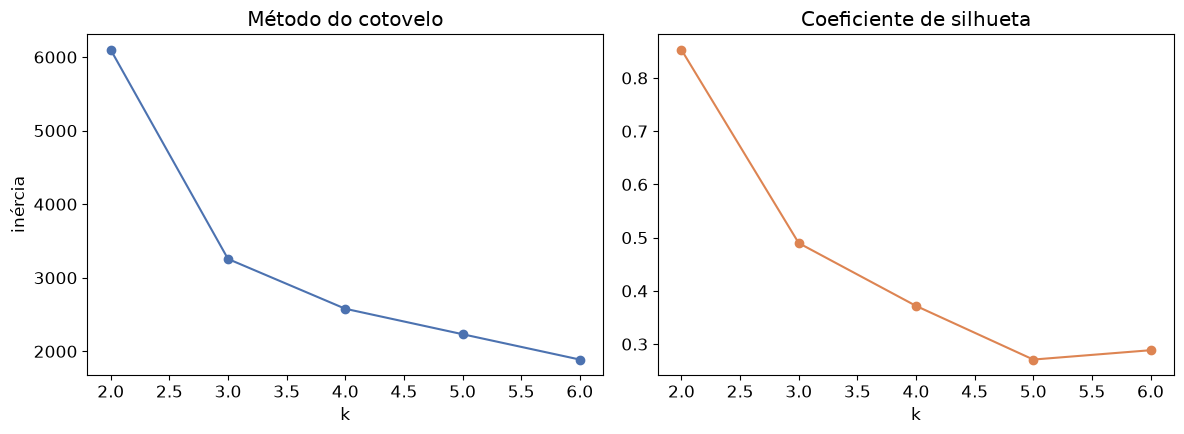

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(resultados_df['k'], resultados_df['inercia'], marker='o', color='#4C72B0')
axes[0].set_title('Método do cotovelo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inércia')

axes[1].plot(resultados_df['k'], resultados_df['silhueta'], marker='o', color='#DD8452')
axes[1].set_title('Coeficiente de silhueta')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('img_escolha_k.png', dpi=110)
plt.show()

A silhueta mais alta é em $k=2$ -- mas isso tende a só separar os poucos dias
mais extremos do resto. Para uma leitura de regimes mais informativa (baixa, média e
alta volatilidade), seguimos com $k=3$, aceitando uma silhueta menor em troca de
uma segmentação mais interpretável -- uma escolha comum na prática, quando o critério
puramente estatístico produz um resultado pouco útil.

## 4. Ajustando o K-Means com k=3

In [6]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
volatilidade = volatilidade.copy()
volatilidade['cluster'] = km_final.labels_

# Rotular os clusters por ordem crescente de volatilidade média do Ibovespa
medias_ibov = volatilidade.groupby('cluster')['ibovespa'].mean().sort_values()
mapa_rotulos = {cluster: rotulo for cluster, rotulo in zip(medias_ibov.index, ['baixa', 'média', 'alta'])}
volatilidade['regime'] = volatilidade['cluster'].map(mapa_rotulos)

print(volatilidade.groupby('regime')[['ibovespa', 'sp500', 'nasdaq', 'stoxx50']].mean())
print()
print(volatilidade['regime'].value_counts())

Ticker    ibovespa      sp500     nasdaq    stoxx50
regime                                             
alta    113.580989  86.495965  84.985862  68.987238
baixa    18.414667  11.045640  14.857280  13.696899
média    24.269340  24.157937  29.704433  25.539523

regime
baixa    1986
média     717
alta       25
Name: count, dtype: int64


## 5. O que o modelo encontrou, sem nenhum rótulo

O cluster de "alta" volatilidade é uma fatia pequena da amostra. Vale checar **quando**
esses dias aconteceram -- sem ter dito ao modelo nada sobre datas de crise.

In [7]:
dias_alta_vol = volatilidade[volatilidade['regime'] == 'alta']
print(f"Total de dias no regime de alta volatilidade: {len(dias_alta_vol)}")
print(f"Primeiro dia: {dias_alta_vol.index.min():%Y-%m-%d}")
print(f"Último dia:   {dias_alta_vol.index.max():%Y-%m-%d}")
print()
print("Distribuição por ano:")
print(dias_alta_vol.index.year.value_counts().sort_index())

Total de dias no regime de alta volatilidade: 25
Primeiro dia: 2020-03-12
Último dia:   2020-04-17

Distribuição por ano:
Date
2020    25
Name: count, dtype: int64


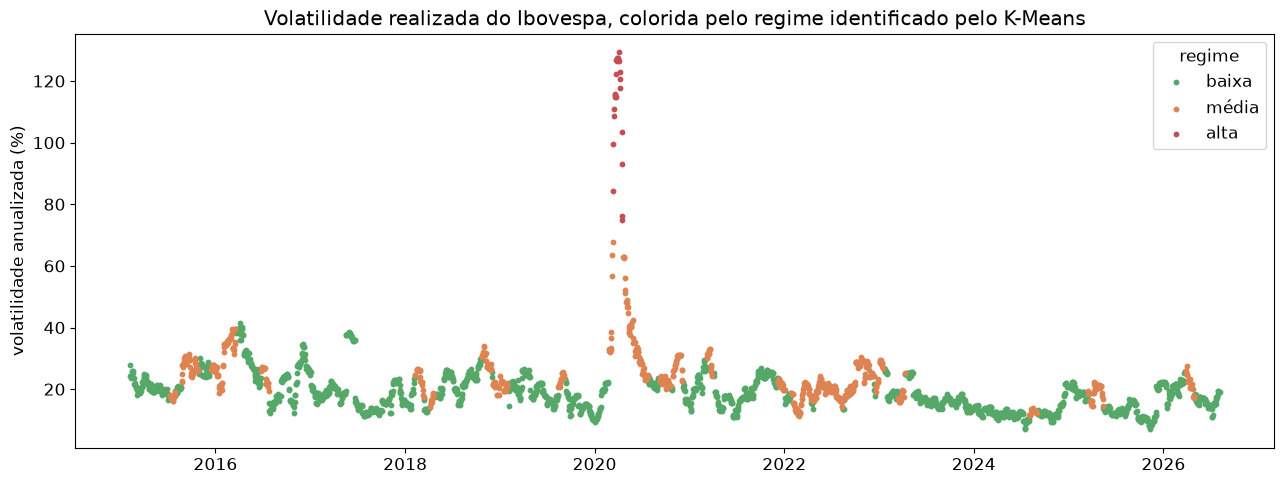

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
cores = {'baixa': '#55A868', 'média': '#DD8452', 'alta': '#C44E52'}
for regime, cor in cores.items():
    subset = volatilidade[volatilidade['regime'] == regime]
    ax.scatter(subset.index, subset['ibovespa'], color=cor, label=regime, s=10)
ax.set_title('Volatilidade realizada do Ibovespa, colorida pelo regime identificado pelo K-Means')
ax.set_ylabel('volatilidade anualizada (%)')
ax.legend(title='regime')
plt.tight_layout()
plt.savefig('img_regimes_volatilidade.png', dpi=110)
plt.show()

A concentração do regime "alta" deve saltar aos olhos no início de 2020 -- a
crise da COVID-19. O modelo não recebeu nenhuma data, nenhum rótulo de "pandemia" ou
"crise": apenas quatro séries de volatilidade, e ele isolou sozinho o período mais
turbulento da amostra como um grupo estatisticamente distinto.

## 6. Comparando com a volatilidade condicional do GARCH

O [Módulo 07](../07_Econometria_I/violacoes_das_hipoteses.ipynb) mostrou que retornos
financeiros têm heterocedasticidade condicional (efeito ARCH). Um jeito de modelar essa
variância diretamente é o **GARCH(1,1)**. Vale comparar a volatilidade condicional
estimada por ele com a volatilidade realizada usada para o clustering -- duas abordagens
bem diferentes (uma é um modelo estatístico paramétrico; a outra é uma estatística móvel
simples seguida de agrupamento) chegando a uma leitura parecida do mercado.

In [9]:
modelo_garch = arch_model(retornos['ibovespa'] * 100, vol='Garch', p=1, q=1, dist='t')
resultado_garch = modelo_garch.fit(disp='off')

vol_condicional_garch = resultado_garch.conditional_volatility * np.sqrt(252)

correlacao = pd.concat([
    volatilidade['ibovespa'].rename('volatilidade_realizada'),
    vol_condicional_garch.rename('volatilidade_garch')
], axis=1).dropna().corr().iloc[0, 1]

print(f"Correlação entre volatilidade realizada (usada no K-Means) e volatilidade condicional do GARCH: {correlacao:.4f}")

Correlação entre volatilidade realizada (usada no K-Means) e volatilidade condicional do GARCH: 0.9662


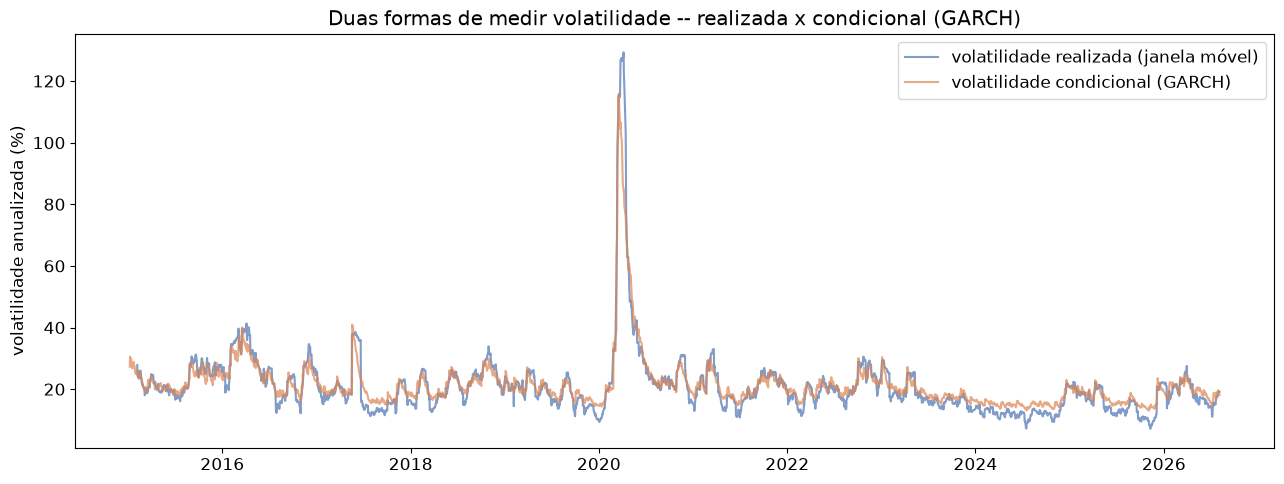

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(volatilidade.index, volatilidade['ibovespa'], label='volatilidade realizada (janela móvel)', color='#4C72B0', alpha=0.7)
ax.plot(vol_condicional_garch.index, vol_condicional_garch, label='volatilidade condicional (GARCH)', color='#DD8452', alpha=0.7)
ax.set_title('Duas formas de medir volatilidade -- realizada x condicional (GARCH)')
ax.set_ylabel('volatilidade anualizada (%)')
ax.legend()
plt.tight_layout()
plt.savefig('img_garch_vs_realizada.png', dpi=110)
plt.show()

## 7. Exercícios de fixação

1. Refaça a clusterização usando apenas 2 features (`ibovespa` e `sp500`, sem
   `nasdaq`/`stoxx50`). O resultado (dias classificados como "alta volatilidade") muda
   muito?
2. Calcule a proporção de dias em cada regime (`baixa`, `média`, `alta`) especificamente
   no ano de 2022 -- foi um ano mais ou menos turbulento que a média da amostra?

In [11]:
# 1.
X_reduzido = StandardScaler().fit_transform(volatilidade[['ibovespa', 'sp500']])
km_reduzido = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_reduzido)

# Identifica qual dos 3 clusters tem a maior volatilidade média do Ibovespa
vol_media_por_cluster = pd.Series(volatilidade['ibovespa'].values).groupby(km_reduzido.labels_).mean()
cluster_alta_vol = vol_media_por_cluster.idxmax()
n_dias_alta_reduzido = (km_reduzido.labels_ == cluster_alta_vol).sum()

print(f"1) Com apenas 2 mercados: {n_dias_alta_reduzido} dias no cluster de maior volatilidade")
print(f"   (versus {len(dias_alta_vol)} dias com as 4 features originais)")

# 2.
prop_2022 = volatilidade.loc['2022', 'regime'].value_counts(normalize=True)
prop_total = volatilidade['regime'].value_counts(normalize=True)
print(f"\n2) Proporção de regimes em 2022:\n{prop_2022}")
print(f"\n   Proporção na amostra inteira:\n{prop_total}")

1) Com apenas 2 mercados: 25 dias no cluster de maior volatilidade
   (versus 25 dias com as 4 features originais)

2) Proporção de regimes em 2022:
regime
média    0.861345
baixa    0.138655
Name: proportion, dtype: float64

   Proporção na amostra inteira:
regime
baixa    0.728006
média    0.262830
alta     0.009164
Name: proportion, dtype: float64


## Encerramento do módulo

Este notebook usa clusterização para reconhecer, sem qualquer rótulo, praticamente o
mesmo fenômeno que os módulos de Estatística Econômica, Econometria e Séries Temporais
descreveram de formas diferentes: mercados financeiros têm regimes de volatilidade, e
crises (como a de 2020) mudam sua estrutura estatística de forma detectável. Junto com
o [`ml_loterias/`](ml_loterias) (rede neural recorrente, um exercício mais experimental
e sem pretensão preditiva), o Módulo 10 -- e a trilha inteira do curso -- está completo.

## Bibliografia
- HASTIE, Trevor; TIBSHIRANI, Robert; FRIEDMAN, Jerome. *The Elements of Statistical Learning*. 2. ed. Springer, 2009.
- BOLLERSLEV, Tim (1986). "Generalized Autoregressive Conditional Heteroskedasticity". *Journal of Econometrics*, 31(3).
- JAMES, Gareth et al. *An Introduction to Statistical Learning*. 2. ed. Springer, 2021.